<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Quantum_Related_Spectrogram_Examples_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [ ]:
%pip install -q uv
!uv pip install --system \
    numpy \
    scipy \
    matplotlib \
    pandas \
    pywavelets \
    ssqueezepy \
    qutip \
    scqubits \
    scikit-rf

In [ ]:
!uv pip install --system \
    qcodes \
    quantify-core \
    quantify-scheduler \
    pyvisa \
    pyvisa-py \
    zhinst-toolkit \
    laboneq \
    pygsti \
    tftb \
    mne \
    qiskit \
    qiskit-dynamics

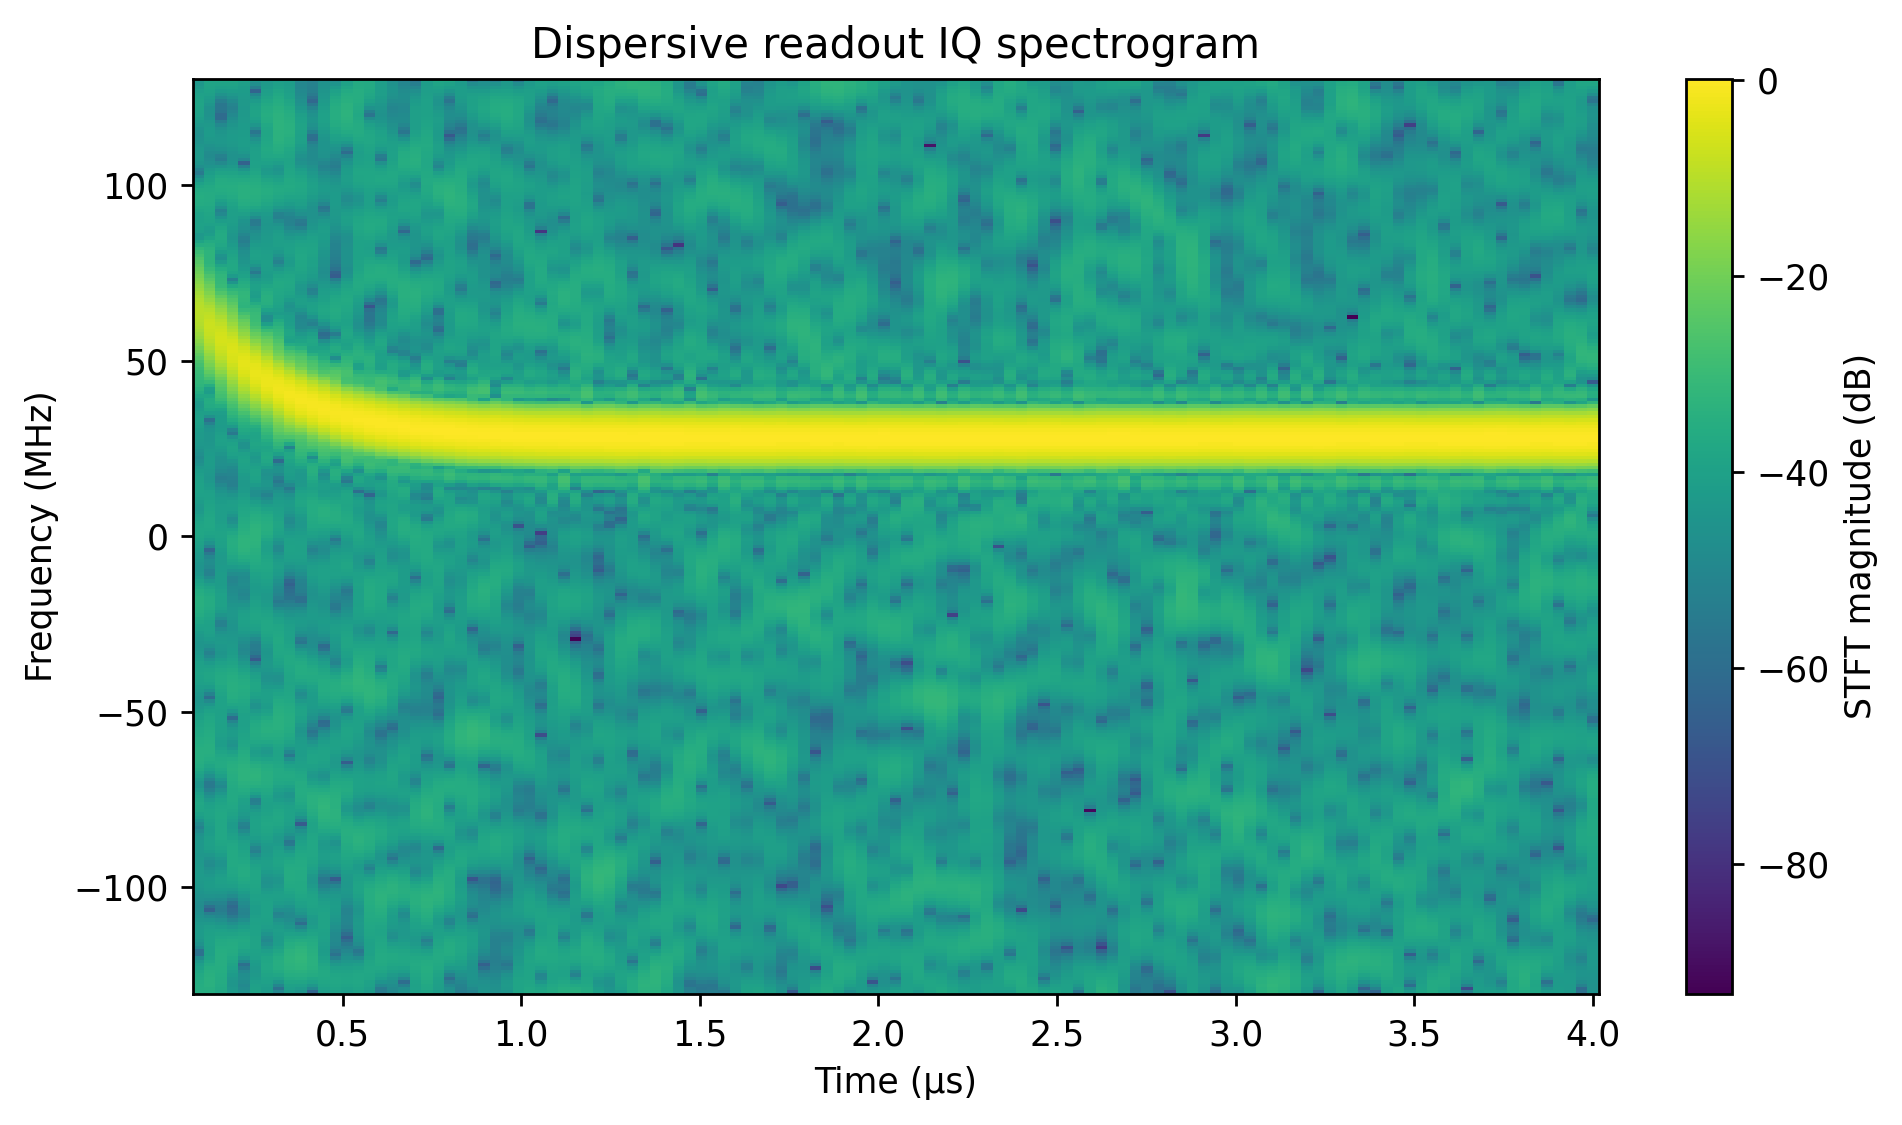

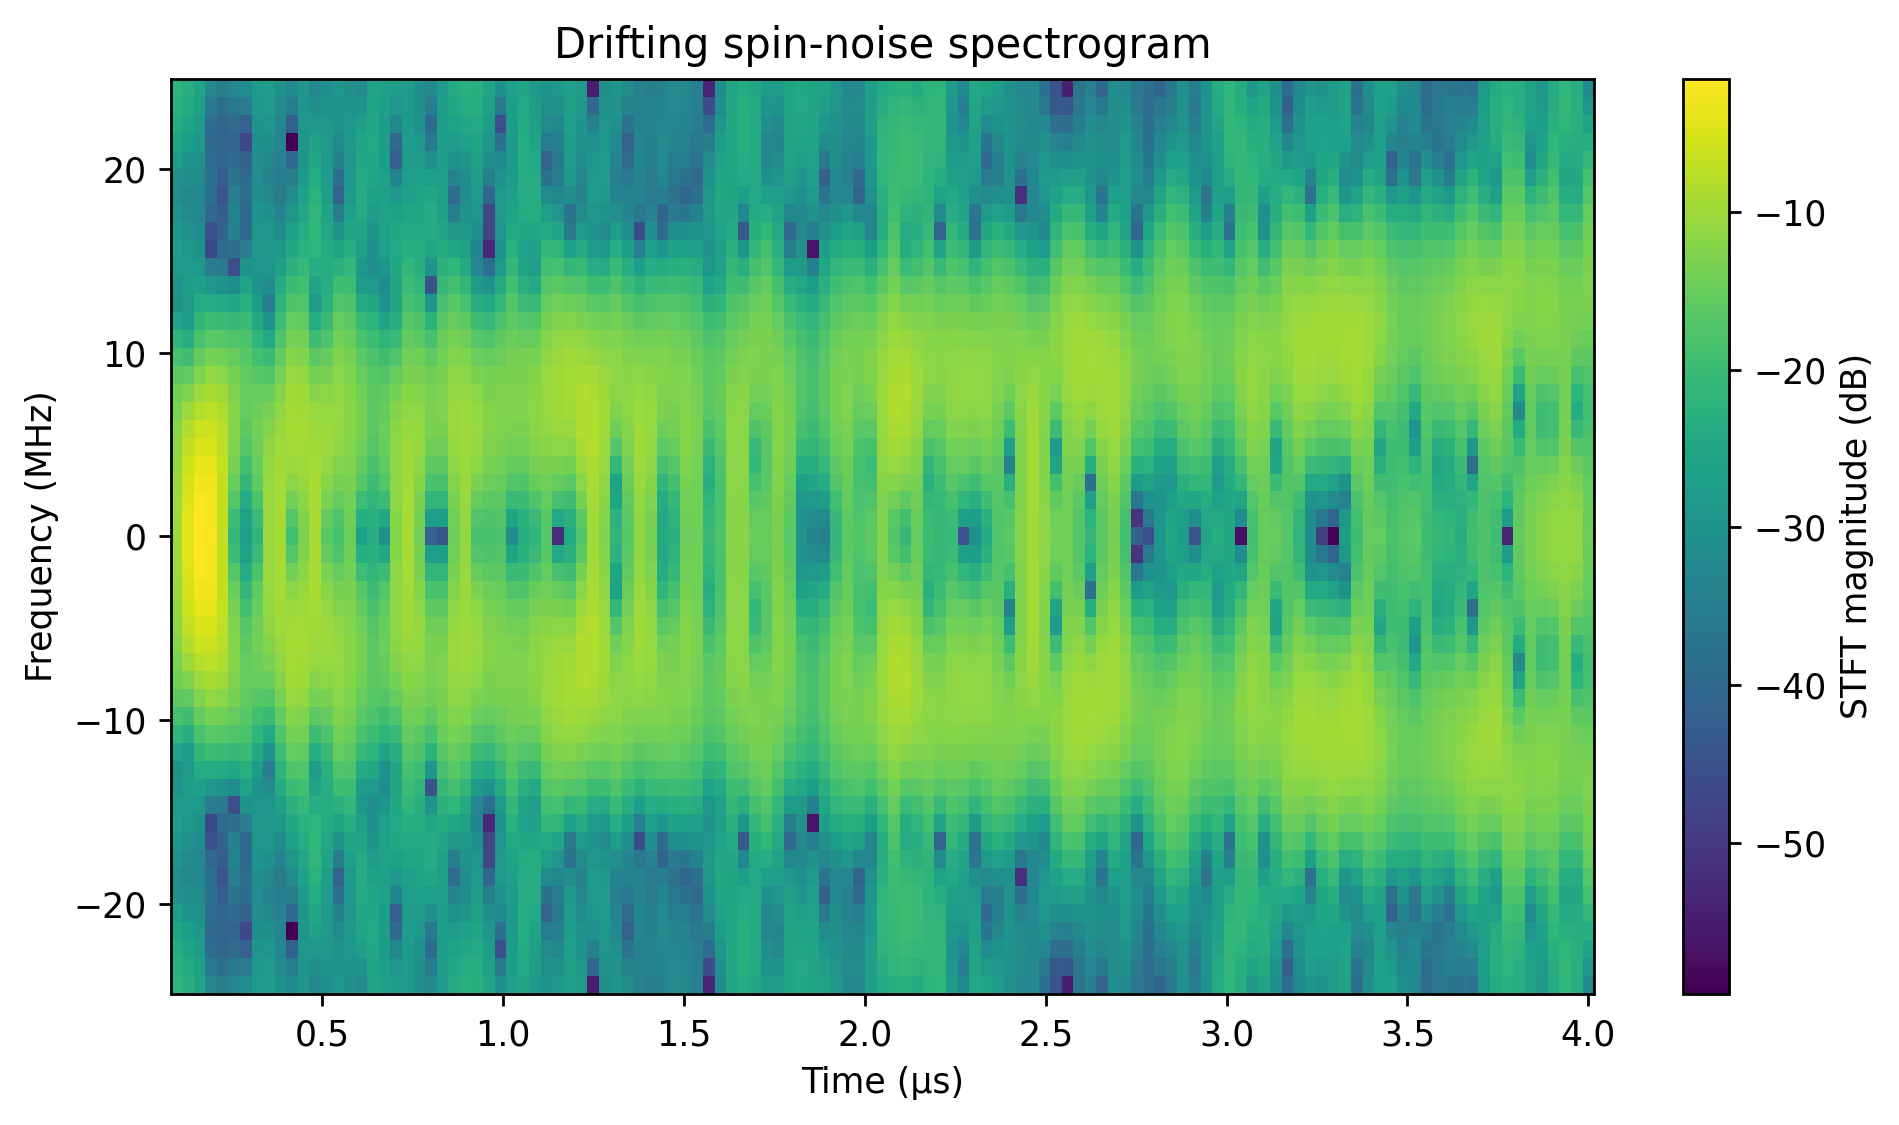

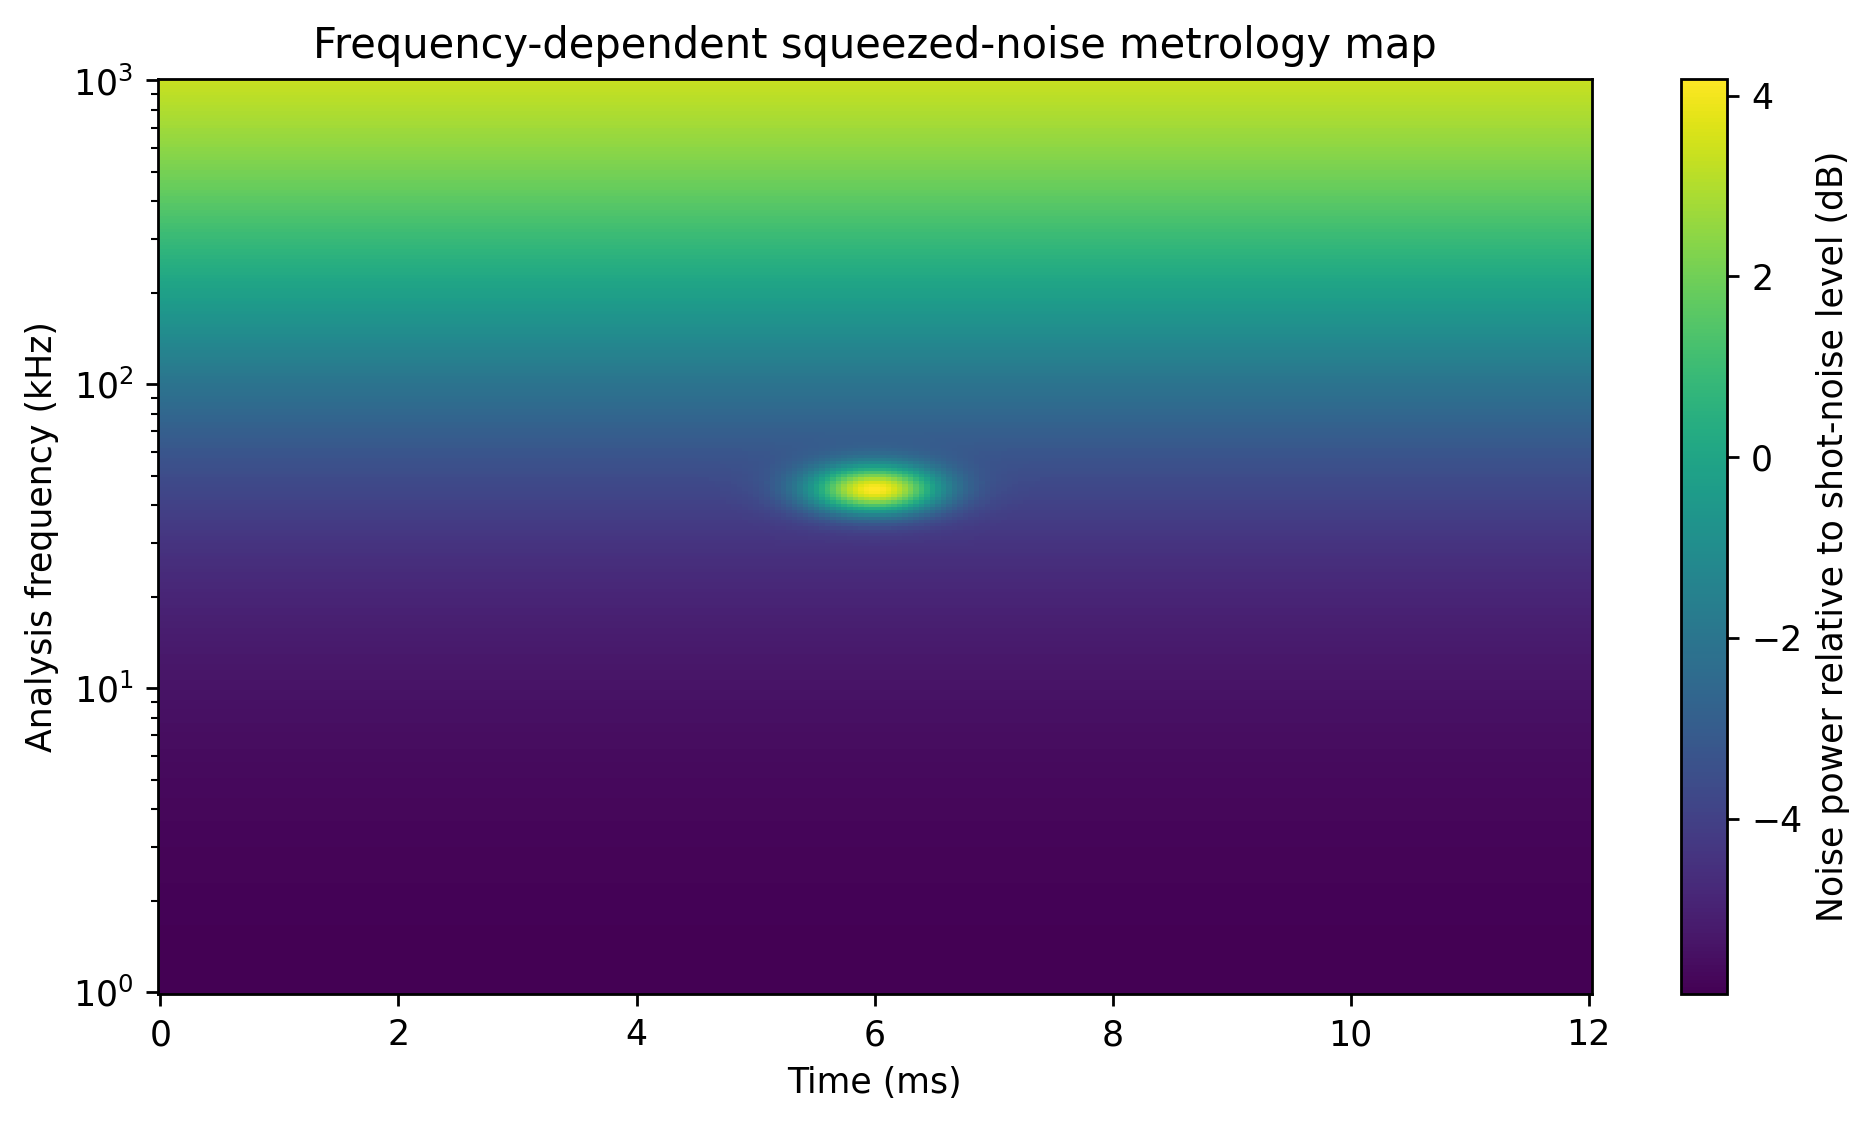

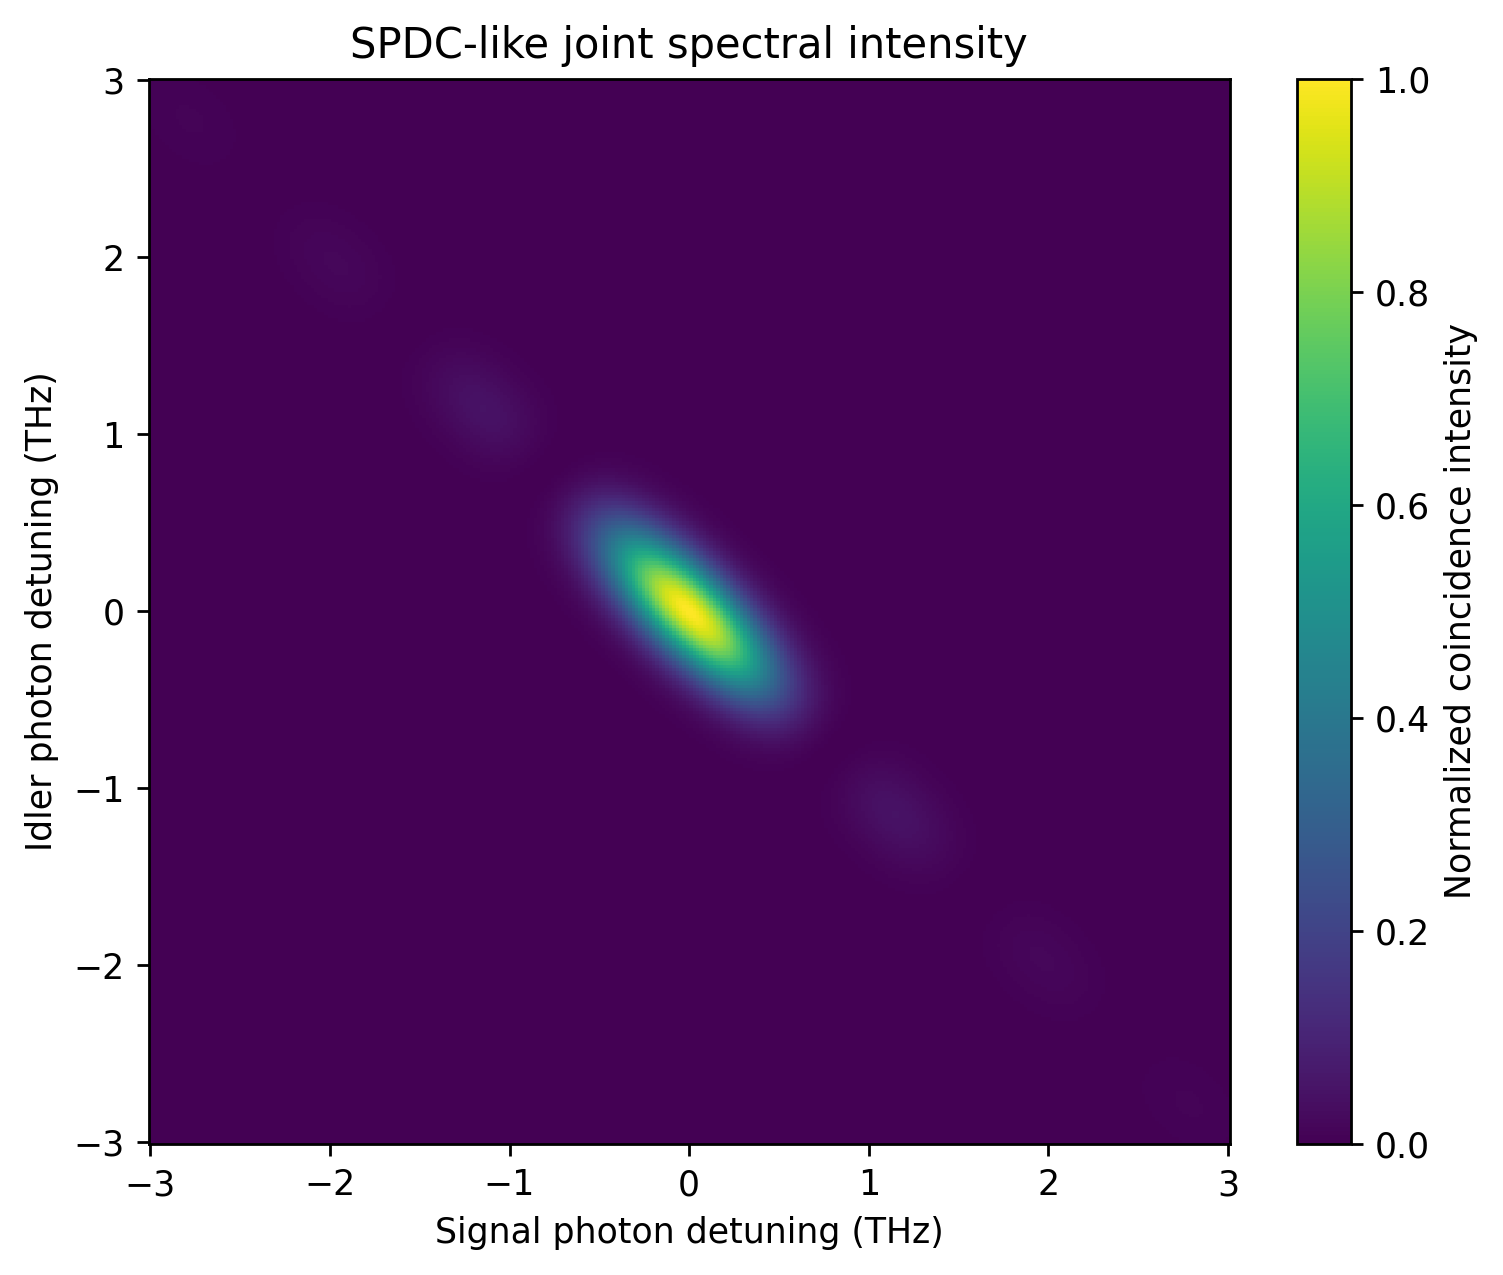

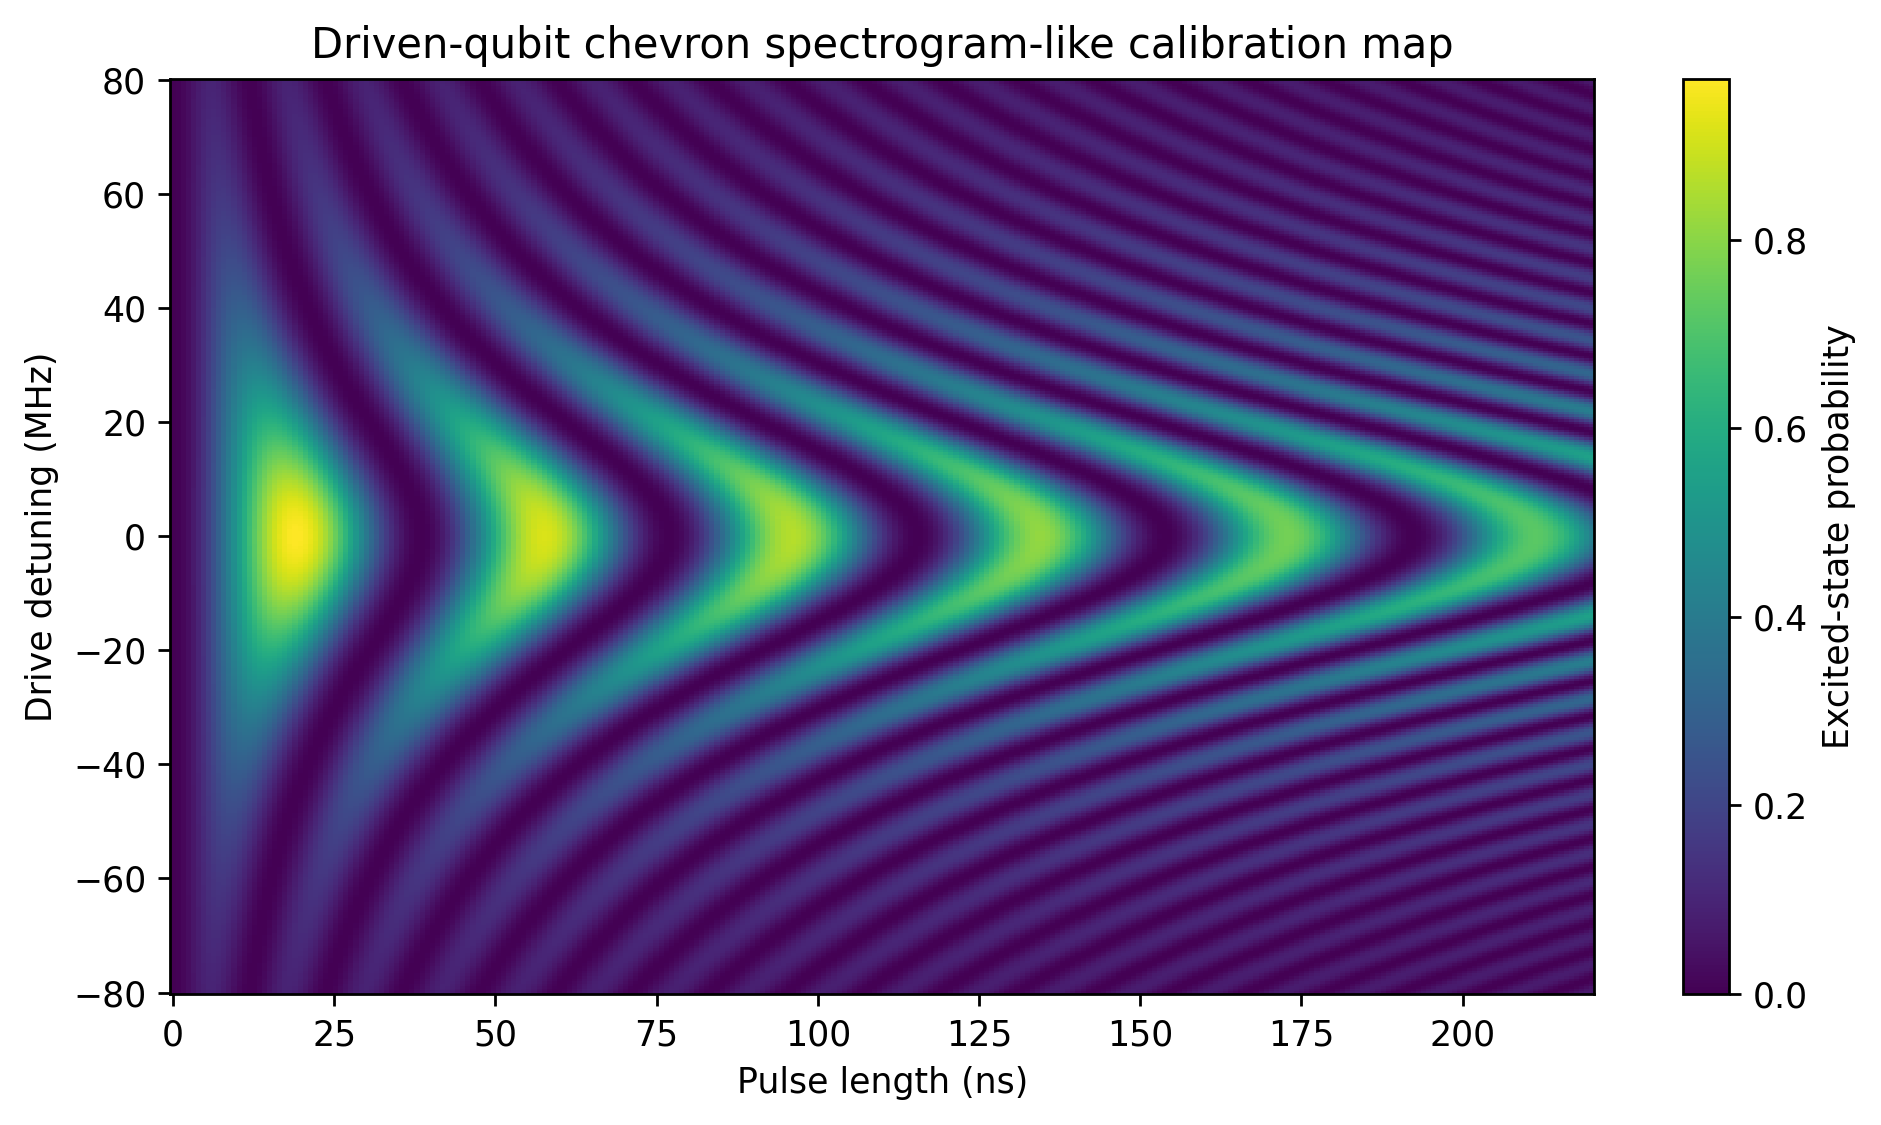

In [5]:
"""Quantum-related spectrogram examples for Google Colab.

The examples include a superconducting-qubit readout spectrogram, a drifting
spin-noise spectrogram, a squeezed-noise metrology map, a photon-pair joint
spectral intensity map, and a driven-qubit chevron calibration map.
"""

from __future__ import annotations

from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
from scipy import signal


# ---------------------------------------------------------------------------
# Control knobs.
# ---------------------------------------------------------------------------
@dataclass(frozen=True)
class SpectrogramConfig:
    """Control knobs for the simulated quantum spectrogram examples."""

    random_seed: int = 7
    sample_rate_hz: float = 2.0e9
    num_samples: int = 8192
    nperseg: int = 384
    noverlap: int = 320
    nfft: int = 2048
    figure_dpi: int = 250

    readout_initial_freq_hz: float = 85.0e6
    readout_excited_freq_hz: float = 28.0e6
    readout_ground_freq_hz: float = -28.0e6
    readout_pull_time_s: float = 0.23e-6
    readout_ringup_time_s: float = 0.18e-6
    readout_noise_scale: float = 0.11

    spin_noise_start_freq_hz: float = 4.0e6
    spin_noise_stop_freq_hz: float = 13.0e6
    spin_noise_modulation_hz: float = 0.6e6
    spin_noise_resonance_scale: float = 0.45
    spin_noise_pink_scale: float = 0.30
    spin_noise_white_scale: float = 0.18

    chevron_detuning_min_hz: float = -80.0e6
    chevron_detuning_max_hz: float = 80.0e6
    chevron_num_detuning_points: int = 360
    chevron_pulse_time_max_s: float = 220.0e-9
    chevron_num_time_points: int = 280
    chevron_rabi_rate_hz: float = 26.0e6
    chevron_decay_time_s: float = 650.0e-9


CONFIG = SpectrogramConfig()
plt.rcParams["figure.dpi"] = CONFIG.figure_dpi


# ---------------------------------------------------------------------------
# Shared utilities.
# ---------------------------------------------------------------------------
def stft_db(
    samples: np.ndarray,
    sample_rate_hz: float,
    nperseg: int,
    noverlap: int,
    nfft: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return shifted STFT magnitude in decibels.

    Args:
        samples: Real or complex waveform samples.
        sample_rate_hz: Sampling rate in hertz.
        nperseg: Number of samples per Hann window.
        noverlap: Number of overlapping samples between windows.
        nfft: FFT length.

    Returns:
        Frequency axis in hertz, time-bin axis in seconds, and STFT magnitude
        in decibels.
    """
    freqs_hz, times_s, zxx = signal.stft(
        samples,
        fs=sample_rate_hz,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        nfft=nfft,
        detrend=False,
        return_onesided=False,
        boundary=None,
        padded=False,
    )
    freqs_hz = np.fft.fftshift(freqs_hz)
    zxx = np.fft.fftshift(zxx, axes=0)
    magnitude_db = 20.0 * np.log10(np.abs(zxx) + np.finfo(float).eps)
    return freqs_hz, times_s, magnitude_db


def plot_time_frequency(
    times_s: np.ndarray,
    freqs_hz: np.ndarray,
    magnitude_db: np.ndarray,
    title: str,
    freq_limit_mhz: float,
) -> None:
    """Render a time-frequency map.

    Args:
        times_s: STFT time-bin axis in seconds.
        freqs_hz: STFT frequency axis in hertz.
        magnitude_db: STFT magnitude in decibels.
        title: Plot title.
        freq_limit_mhz: Symmetric displayed frequency limit in megahertz.
    """
    freq_mhz = freqs_hz / 1.0e6
    time_us = times_s * 1.0e6
    mask = np.abs(freq_mhz) <= freq_limit_mhz

    plt.figure(figsize=(8.0, 4.6))
    mesh = plt.pcolormesh(
        time_us,
        freq_mhz[mask],
        magnitude_db[mask, :],
        shading="auto",
    )
    plt.xlabel("Time (µs)")
    plt.ylabel("Frequency (MHz)")
    plt.title(title)
    plt.colorbar(mesh, label="STFT magnitude (dB)")
    plt.tight_layout()
    plt.show()


def pink_noise(num_samples: int, rng: np.random.Generator) -> np.ndarray:
    """Generate approximate 1/f noise with random Fourier phases.

    Args:
        num_samples: Number of time-domain samples.
        rng: NumPy random number generator.

    Returns:
        Normalized approximate pink-noise trace.
    """
    freqs = np.fft.rfftfreq(num_samples)
    scale = np.ones_like(freqs)
    scale[1:] = 1.0 / np.sqrt(freqs[1:])

    phases = rng.normal(size=freqs.size) + 1j * rng.normal(size=freqs.size)
    spectrum = scale * phases
    noise = np.fft.irfft(spectrum, n=num_samples)
    return noise / np.std(noise)


# ---------------------------------------------------------------------------
# Example 1: Dispersive readout IQ spectrogram.
# ---------------------------------------------------------------------------
def simulate_readout_trace(
    config: SpectrogramConfig,
    qubit_state: str = "excited",
) -> tuple[np.ndarray, np.ndarray]:
    """Simulate a complex heterodyne readout trace.

    Args:
        config: Spectrogram simulation configuration.
        qubit_state: Either "excited" or "ground".

    Returns:
        Time axis in seconds and complex heterodyne readout samples.
    """
    rng = np.random.default_rng(config.random_seed)
    time_s = np.arange(config.num_samples) / config.sample_rate_hz

    if qubit_state == "excited":
        final_freq_hz = config.readout_excited_freq_hz
    elif qubit_state == "ground":
        final_freq_hz = config.readout_ground_freq_hz
    else:
        raise ValueError('qubit_state must be either "excited" or "ground".')

    inst_freq_hz = final_freq_hz + (
        config.readout_initial_freq_hz - final_freq_hz
    ) * np.exp(-time_s / config.readout_pull_time_s)

    phase_rad = (
        2.0 * np.pi * np.cumsum(inst_freq_hz) / config.sample_rate_hz
    )
    envelope = 1.0 - np.exp(-time_s / config.readout_ringup_time_s)

    readout = envelope * np.exp(1j * phase_rad)
    noise = config.readout_noise_scale * (
        rng.normal(size=time_s.size) + 1j * rng.normal(size=time_s.size)
    )

    return time_s, readout + noise


def plot_readout_spectrogram(config: SpectrogramConfig) -> None:
    """Render a dispersive readout IQ spectrogram.

    Args:
        config: Spectrogram simulation configuration.
    """
    _, readout = simulate_readout_trace(config, qubit_state="excited")
    freqs_hz, bins_s, mag_db = stft_db(
        readout,
        config.sample_rate_hz,
        config.nperseg,
        config.noverlap,
        config.nfft,
    )
    plot_time_frequency(
        bins_s,
        freqs_hz,
        mag_db,
        "Dispersive readout IQ spectrogram",
        freq_limit_mhz=130.0,
    )


# ---------------------------------------------------------------------------
# Example 2: Spin-noise or quantum-noise spectrogram.
# ---------------------------------------------------------------------------
def simulate_spin_noise_trace(
    config: SpectrogramConfig,
) -> tuple[np.ndarray, np.ndarray]:
    """Simulate a drifting spin-noise resonance embedded in 1/f noise.

    Args:
        config: Spectrogram simulation configuration.

    Returns:
        Time axis in seconds and simulated spin-noise samples.
    """
    rng = np.random.default_rng(config.random_seed + 1)
    time_s = np.arange(config.num_samples) / config.sample_rate_hz

    drift_hz = config.spin_noise_start_freq_hz + (
        config.spin_noise_stop_freq_hz - config.spin_noise_start_freq_hz
    ) * time_s / time_s[-1]
    modulation_hz = config.spin_noise_modulation_hz * np.sin(
        2.0 * np.pi * time_s / time_s[-1]
    )
    inst_freq_hz = drift_hz + modulation_hz
    phase_rad = (
        2.0 * np.pi * np.cumsum(inst_freq_hz) / config.sample_rate_hz
    )

    resonance = config.spin_noise_resonance_scale * np.sin(phase_rad)
    background = config.spin_noise_pink_scale * pink_noise(
        config.num_samples,
        rng,
    )
    white = config.spin_noise_white_scale * rng.normal(
        size=config.num_samples,
    )

    return time_s, resonance + background + white


def plot_spin_noise_spectrogram(config: SpectrogramConfig) -> None:
    """Render a drifting spin-noise spectrogram.

    Args:
        config: Spectrogram simulation configuration.
    """
    _, spin_noise = simulate_spin_noise_trace(config)
    freqs_hz, bins_s, mag_db = stft_db(
        spin_noise,
        config.sample_rate_hz,
        config.nperseg,
        config.noverlap,
        config.nfft,
    )
    plot_time_frequency(
        bins_s,
        freqs_hz,
        mag_db,
        "Drifting spin-noise spectrogram",
        freq_limit_mhz=25.0,
    )


# ---------------------------------------------------------------------------
# Example 3: Quantum-enhanced metrology noise map.
# ---------------------------------------------------------------------------
def plot_squeezed_noise_map() -> None:
    """Render a model time-frequency map for squeezed-noise metrology."""
    time_ms = np.linspace(0.0, 12.0, 260)
    freq_hz = np.geomspace(1.0e3, 1.0e6, 280)
    time_grid, freq_grid = np.meshgrid(time_ms, freq_hz)

    squeeze_db = -6.0 + 11.0 * (freq_grid / (freq_grid + 1.8e5))

    time_gate = np.exp(-((time_grid - 6.0) / 0.55) ** 2)
    frequency_gate = np.exp(
        -((np.log10(freq_grid) - np.log10(4.5e4)) / 0.08) ** 2
    )
    metrology_signal = 8.0 * time_gate * frequency_gate
    noise_map_db = squeeze_db + metrology_signal

    plt.figure(figsize=(8.0, 4.6))
    mesh = plt.pcolormesh(
        time_ms,
        freq_hz / 1.0e3,
        noise_map_db,
        shading="auto",
    )
    plt.yscale("log")
    plt.xlabel("Time (ms)")
    plt.ylabel("Analysis frequency (kHz)")
    plt.title("Frequency-dependent squeezed-noise metrology map")
    plt.colorbar(mesh, label="Noise power relative to shot-noise level (dB)")
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# Example 4: Photon-pair joint spectral intensity.
# ---------------------------------------------------------------------------
def plot_photon_pair_jsi() -> None:
    """Render a joint spectral intensity map for photon-pair sources."""
    signal_detuning = np.linspace(-3.0, 3.0, 320)
    idler_detuning = np.linspace(-3.0, 3.0, 320)
    sig_grid, idl_grid = np.meshgrid(signal_detuning, idler_detuning)

    pump_width = 0.45
    phase_match_width = 1.6

    pump_envelope = np.exp(-((sig_grid + idl_grid) / pump_width) ** 2)
    phase_match = np.sinc((sig_grid - idl_grid) / phase_match_width)
    jsi = (pump_envelope * phase_match) ** 2
    jsi = jsi / np.max(jsi)

    plt.figure(figsize=(6.2, 5.2))
    mesh = plt.pcolormesh(
        signal_detuning,
        idler_detuning,
        jsi,
        shading="auto",
    )
    plt.xlabel("Signal photon detuning (THz)")
    plt.ylabel("Idler photon detuning (THz)")
    plt.title("SPDC-like joint spectral intensity")
    plt.colorbar(mesh, label="Normalized coincidence intensity")
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# Example 5: Driven-qubit chevron map.
# ---------------------------------------------------------------------------
def plot_qubit_chevron(config: SpectrogramConfig) -> None:
    """Render a Rabi chevron calibration map.

    Args:
        config: Spectrogram simulation configuration.
    """
    detuning_hz = np.linspace(
        config.chevron_detuning_min_hz,
        config.chevron_detuning_max_hz,
        config.chevron_num_detuning_points,
    )
    pulse_time_s = np.linspace(
        0.0,
        config.chevron_pulse_time_max_s,
        config.chevron_num_time_points,
    )

    delta_rad_s = 2.0 * np.pi * detuning_hz[:, None]
    omega_rad_s = 2.0 * np.pi * config.chevron_rabi_rate_hz
    omega_eff_rad_s = np.sqrt(omega_rad_s**2 + delta_rad_s**2)

    drive_factor = (omega_rad_s / omega_eff_rad_s) ** 2
    rabi_kernel = np.sin(
        0.5 * omega_eff_rad_s * pulse_time_s[None, :]
    ) ** 2
    decay_envelope = np.exp(-pulse_time_s[None, :] / config.chevron_decay_time_s)

    probability = drive_factor * rabi_kernel * decay_envelope

    plt.figure(figsize=(8.0, 4.6))
    mesh = plt.pcolormesh(
        pulse_time_s * 1.0e9,
        detuning_hz / 1.0e6,
        probability,
        shading="auto",
    )
    plt.xlabel("Pulse length (ns)")
    plt.ylabel("Drive detuning (MHz)")
    plt.title("Driven-qubit chevron spectrogram-like calibration map")
    plt.colorbar(mesh, label="Excited-state probability")
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# Run all examples.
# ---------------------------------------------------------------------------
def run_all_examples(config: SpectrogramConfig) -> None:
    """Render all quantum-related spectrogram examples.

    Args:
        config: Spectrogram simulation configuration.
    """
    plot_readout_spectrogram(config)
    plot_spin_noise_spectrogram(config)
    plot_squeezed_noise_map()
    plot_photon_pair_jsi()
    plot_qubit_chevron(config)


run_all_examples(CONFIG)